In [36]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from tabulate import tabulate
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
from scipy.signal import detrend
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.simplefilter('ignore', InterpolationWarning)

In [38]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "akhiljethwa/world-energy-statistics"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/World Energy Overview.csv")

print(df.head())
print(df.info())
print(df.describe())
duplicates_count = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates_count}")

Dataset path: data/kagglehub_cache\datasets\akhiljethwa\world-energy-statistics\versions\2
         Date  Total Fossil Fuels Production  \
0  1973-01-31                       4.932632   
1  1973-02-28                       4.729582   
2  1973-03-31                       4.946902   
3  1973-04-30                       4.716271   
4  1973-05-31                       4.956995   

   Nuclear Electric Power Production  Total Renewable Energy Production  \
0                           0.068103                           0.403981   
1                           0.064634                           0.360900   
2                           0.072494                           0.400161   
3                           0.064070                           0.380470   
4                           0.062111                           0.392141   

   Total Primary Energy Production  Primary Energy Imports  \
0                         5.404715                1.173080   
1                         5.155115           

Проверка пропусков

In [39]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.to_period('M')

full_range = pd.period_range(start='1973-01', end='2022-11', freq='M')

missing = full_range.difference(df['Date'])

print("Пропущенные месяцы:", missing)
print("Количество пропусков:", len(missing))

Пропущенные месяцы: PeriodIndex([], dtype='period[M]')
Количество пропусков: 0


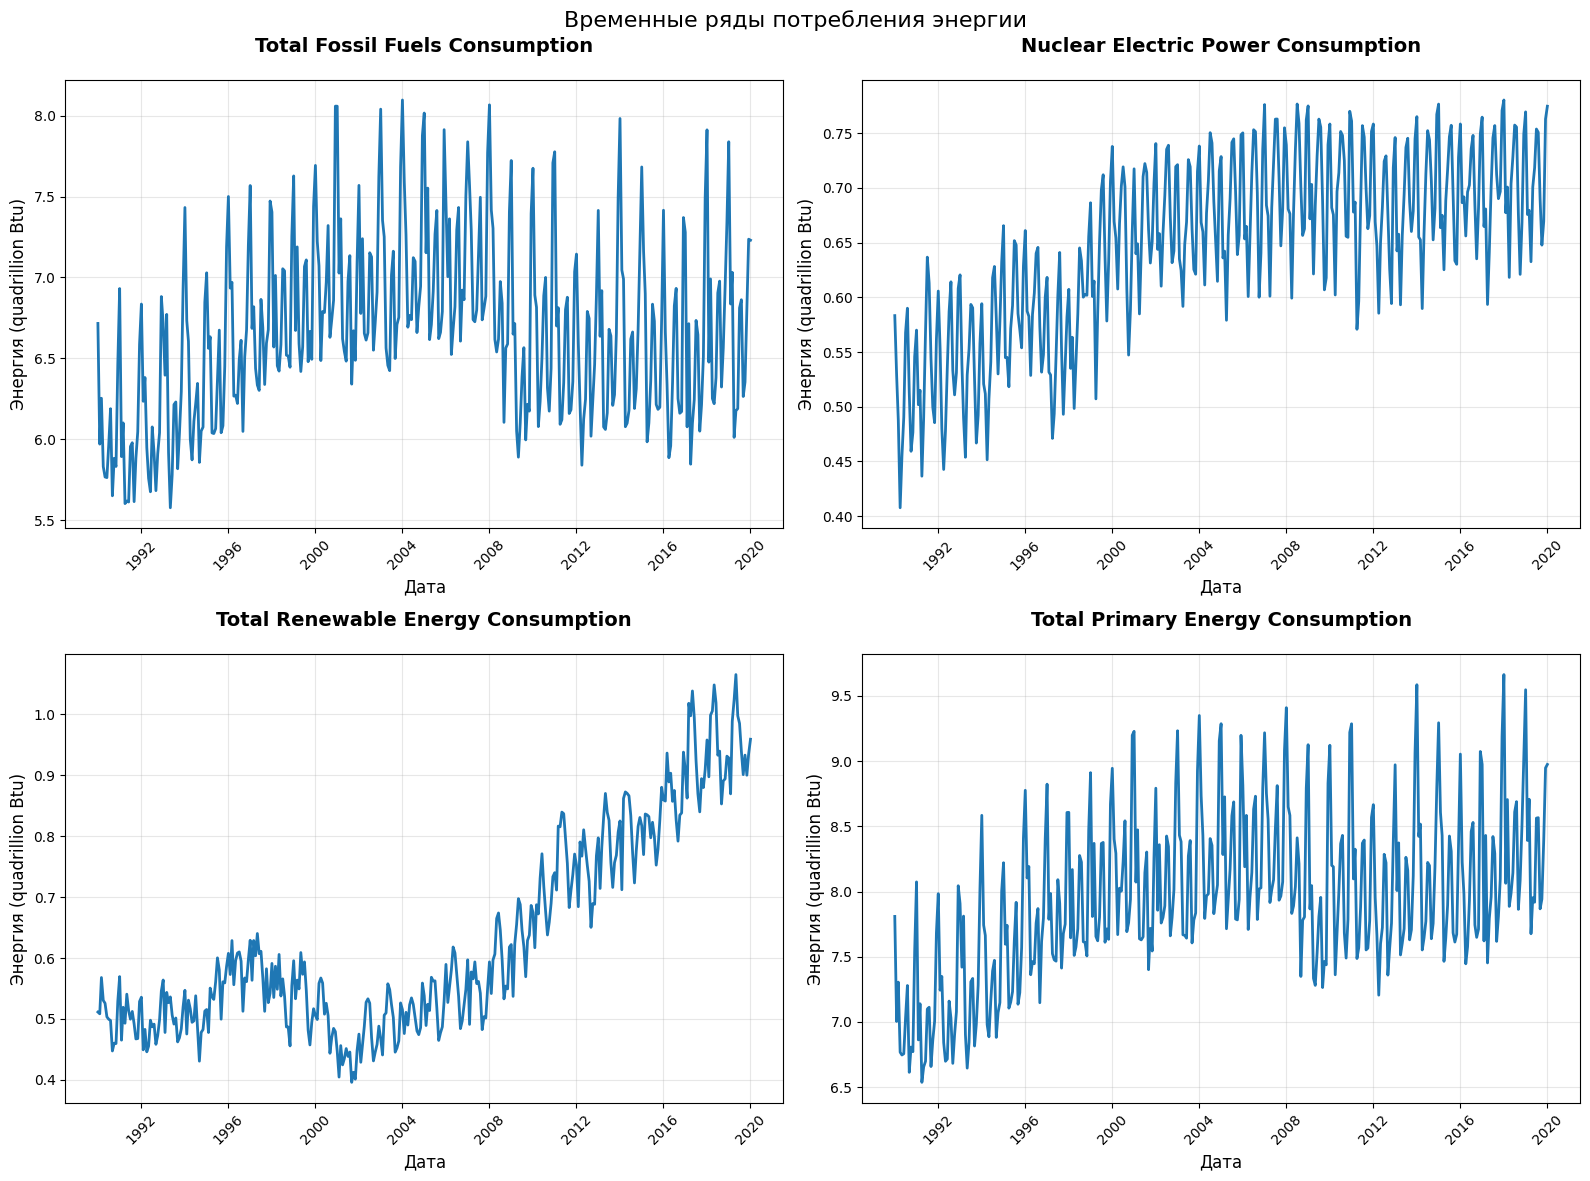

In [40]:
# срез данных с 1990 года
df_cropped = df[df['Date'].between('1990-01', '2020-01')]

consumption_cols = [col for col in df_cropped.columns if 'Consumption' in col]
cols = consumption_cols + ['Date']
df_cons = df_cropped[cols]
df_cons.set_index('Date', inplace=True)
df_cons.index = df_cons.index.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(consumption_cols):
    axes[i].plot(df_cons.index, df_cons[col], linewidth=2)
    axes[i].set_title(col, fontsize=14, fontweight='bold', pad=20)
    axes[i].set_xlabel('Дата', fontsize=12)
    axes[i].set_ylabel('Энергия (quadrillion Btu)', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Временные ряды потребления энергии', fontsize=16)
plt.tight_layout()
plt.show()

import numpy as np

df_log = np.log(df_cons)

df_log['sin_month'] = np.sin(2 * np.pi * df_log.index.month / 12)
df_log['cos_month'] = np.cos(2 * np.pi * df_log.index.month / 12)

# Fossil Fuels

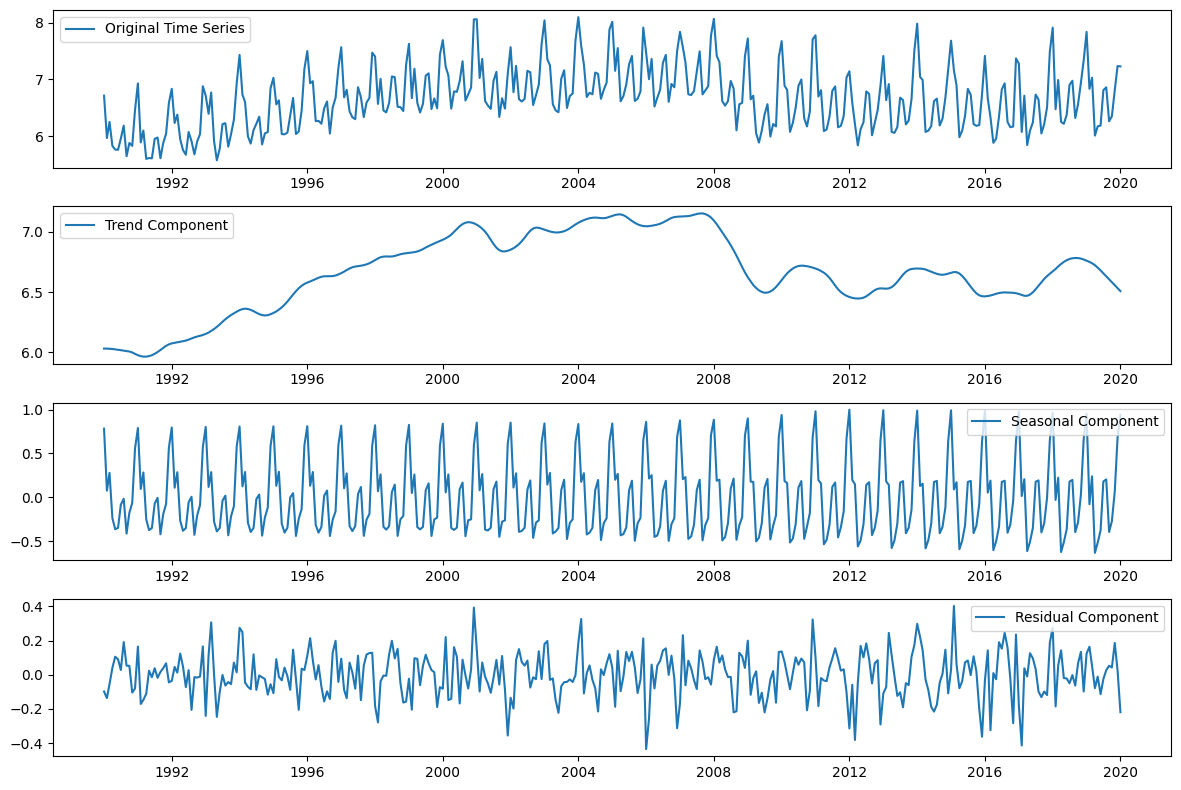

In [41]:
stl_fossil = STL(df_cons['Total Fossil Fuels Consumption'], seasonal=13)
result_fossil = stl_fossil.fit()
# Извлечение компонентов
trend = result_fossil.trend
seasonal = result_fossil.seasonal
residual = result_fossil.resid

# Построение графика декомпозиции
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df_cons['Total Fossil Fuels Consumption'], label='Original Time Series')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend Component')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal Component')
plt.legend(loc='upper right')
plt.subplot(414)
plt.plot(residual, label='Residual Component')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

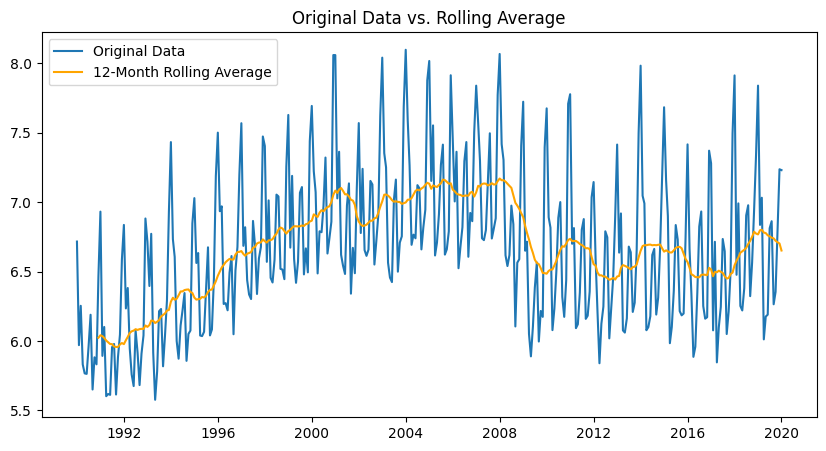

In [42]:
# Расчет скользящего среднего за 12 месяцев
df_cons['rolling_avg'] = df_cons['Total Fossil Fuels Consumption'].rolling(window=12).mean()

plt.figure(figsize=(10, 5))
plt.plot(df_cons['Total Fossil Fuels Consumption'], label='Original Data')
plt.plot(df_cons['rolling_avg'], label='12-Month Rolling Average', color='orange')
plt.title('Original Data vs. Rolling Average')
plt.legend()
plt.show()

# Nuclear ELectricity

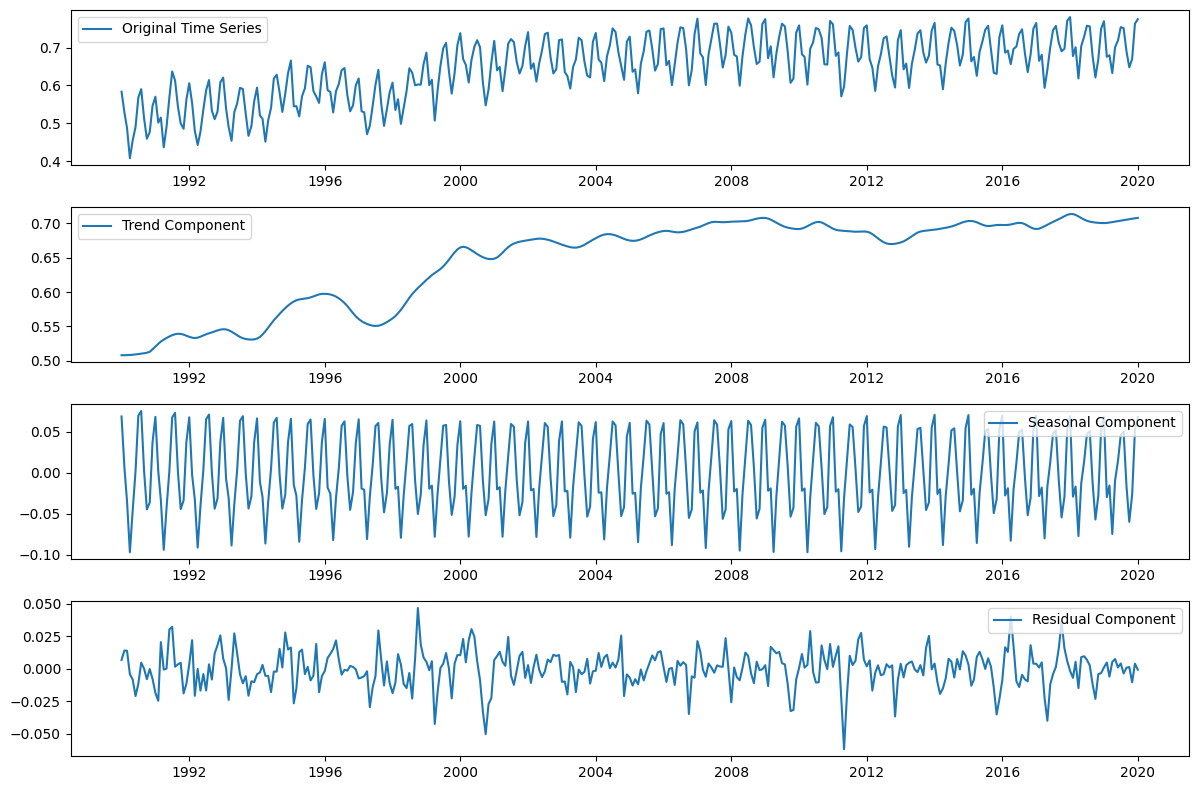

In [43]:
stl_nuclear = STL(df_cons['Nuclear Electric Power Consumption'], seasonal=13)
result_nuclear = stl_nuclear.fit()
# Извлечение компонентов
trend = result_nuclear.trend
seasonal = result_nuclear.seasonal
residual = result_nuclear.resid

# Построение графика декомпозиции
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df_cons['Nuclear Electric Power Consumption'], label='Original Time Series')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend Component')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal Component')
plt.legend(loc='upper right')
plt.subplot(414)
plt.plot(residual, label='Residual Component')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

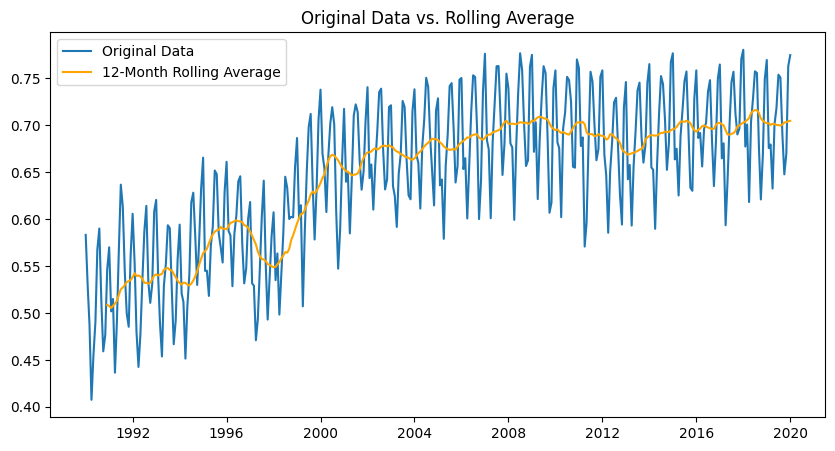

In [44]:
# Расчет скользящего среднего за 12 месяцев
df_cons['rolling_avg'] = df_cons['Nuclear Electric Power Consumption'].rolling(window=12).mean()

plt.figure(figsize=(10, 5))
plt.plot(df_cons['Nuclear Electric Power Consumption'], label='Original Data')
plt.plot(df_cons['rolling_avg'], label='12-Month Rolling Average', color='orange')
plt.title('Original Data vs. Rolling Average')
plt.legend()
plt.show()

# Тест Дики-Фуллера

In [45]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    return result[1]

print("AFK для рядов")

DF_values = []
for column in consumption_cols:
    p_value = check_stationarity(df_cons[column])
    DF_values.append(p_value)
    print(f"Column '{column}': p‑value = {p_value}")

AFK для рядов
Column 'Total Fossil Fuels Consumption': p‑value = 0.135712151212935
Column 'Nuclear Electric Power Consumption': p‑value = 0.27817749297895356
Column 'Total Renewable Energy Consumption': p‑value = 0.9858095816996907
Column 'Total Primary Energy Consumption': p‑value = 0.08700144855149383


# Тест Тест Квятковского — Филлипса — Шмидта — Шина

In [46]:
def check_kpss_stationarity(timeseries, regression='c'):
    result = kpss(timeseries.dropna(), regression=regression, nlags='auto')
    p_val = result[1]
    return p_val

print("KPSS для рядов")

KPSS_values = []
for column in consumption_cols:
    p_value = check_kpss_stationarity(df_cons[column])
    KPSS_values.append(p_value)
    print(f"Column '{column}': p‑value = {p_value}")

KPSS для рядов
Column 'Total Fossil Fuels Consumption': p‑value = 0.01
Column 'Nuclear Electric Power Consumption': p‑value = 0.01
Column 'Total Renewable Energy Consumption': p‑value = 0.01
Column 'Total Primary Energy Consumption': p‑value = 0.01


Сводная таблица метрик

In [47]:
table_data = []
for i, column in enumerate(consumption_cols):
    table_data.append([column, f"{DF_values[i]:.5f}", f"{KPSS_values[i]:.5f}"])

print(tabulate(
    table_data,
    headers=["Column", "ADF p-value", "KPSS p-value"],
    tablefmt="grid",
    floatfmt=".5f"
))

+------------------------------------+---------------+----------------+
| Column                             |   ADF p-value |   KPSS p-value |
+====================================+===============+================+
| Total Fossil Fuels Consumption     |       0.13571 |        0.01000 |
+------------------------------------+---------------+----------------+
| Nuclear Electric Power Consumption |       0.27818 |        0.01000 |
+------------------------------------+---------------+----------------+
| Total Renewable Energy Consumption |       0.98581 |        0.01000 |
+------------------------------------+---------------+----------------+
| Total Primary Energy Consumption   |       0.08700 |        0.01000 |
+------------------------------------+---------------+----------------+


# Детрендирование

Линейный detrend

In [48]:
df_detrend = pd.DataFrame(
    index=df_cons.index,
    columns=consumption_cols,
    data=detrend(df_cons[consumption_cols])
)

DF_values = []
for column in consumption_cols:
    p_value = check_stationarity(df_detrend[column])
    DF_values.append(p_value)

KPSS_values = []
for column in consumption_cols:
    p_value = check_kpss_stationarity(df_detrend[column])
    KPSS_values.append(p_value)

table_data = []
for i, column in enumerate(consumption_cols):
    table_data.append([column, f"{DF_values[i]:.5f}", f"{KPSS_values[i]:.5f}"])

print(tabulate(
    table_data,
    headers=["Column", "ADF p-value", "KPSS p-value"],
    tablefmt="grid",
    floatfmt=".5f"
))

+------------------------------------+---------------+----------------+
| Column                             |   ADF p-value |   KPSS p-value |
+====================================+===============+================+
| Total Fossil Fuels Consumption     |       0.10819 |        0.01000 |
+------------------------------------+---------------+----------------+
| Nuclear Electric Power Consumption |       0.06910 |        0.01000 |
+------------------------------------+---------------+----------------+
| Total Renewable Energy Consumption |       0.22150 |        0.01000 |
+------------------------------------+---------------+----------------+
| Total Primary Energy Consumption   |       0.16073 |        0.01000 |
+------------------------------------+---------------+----------------+


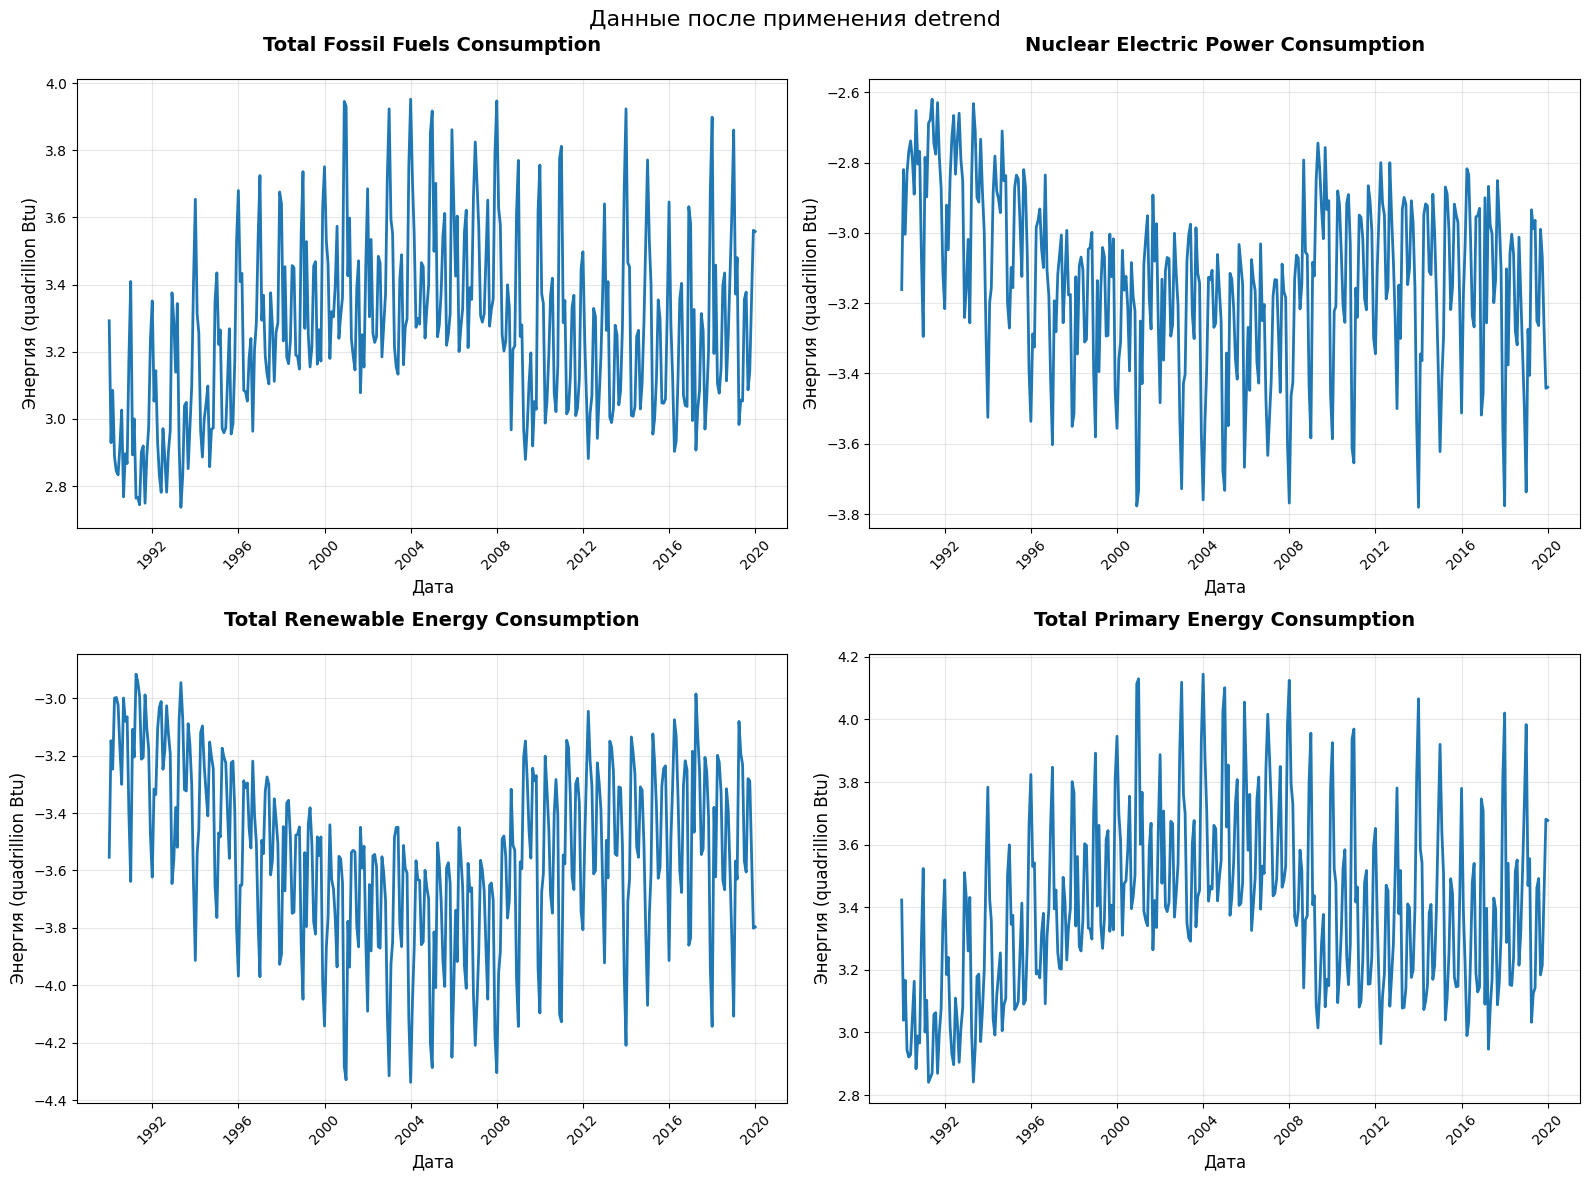

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(consumption_cols):
    axes[i].plot(df_detrend.index, df_detrend[col], linewidth=2)
    axes[i].set_title(col, fontsize=14, fontweight='bold', pad=20)
    axes[i].set_xlabel('Дата', fontsize=12)
    axes[i].set_ylabel('Энергия (quadrillion Btu)', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Данные после применения detrend', fontsize=16)
plt.tight_layout()
plt.show()

Дифферинцирование

In [50]:
df_diff = df_detrend.diff().dropna()

DF_values = []
for column in consumption_cols:
    p_value = check_stationarity(df_diff[column])
    DF_values.append(p_value)

KPSS_values = []
for column in consumption_cols:
    p_value = check_kpss_stationarity(df_diff[column])
    KPSS_values.append(p_value)

table_data = []
for i, column in enumerate(consumption_cols):
    table_data.append([column, f"{DF_values[i]:.5f}", f"{KPSS_values[i]:.5f}"])

print(tabulate(
    table_data,
    headers=["Column", "ADF p-value", "KPSS p-value"],
    tablefmt="grid",
    floatfmt=".5f"
))

+------------------------------------+---------------+----------------+
| Column                             |   ADF p-value |   KPSS p-value |
+====================================+===============+================+
| Total Fossil Fuels Consumption     |       0.00000 |        0.07091 |
+------------------------------------+---------------+----------------+
| Nuclear Electric Power Consumption |       0.00000 |        0.10000 |
+------------------------------------+---------------+----------------+
| Total Renewable Energy Consumption |       0.00001 |        0.10000 |
+------------------------------------+---------------+----------------+
| Total Primary Energy Consumption   |       0.00001 |        0.10000 |
+------------------------------------+---------------+----------------+


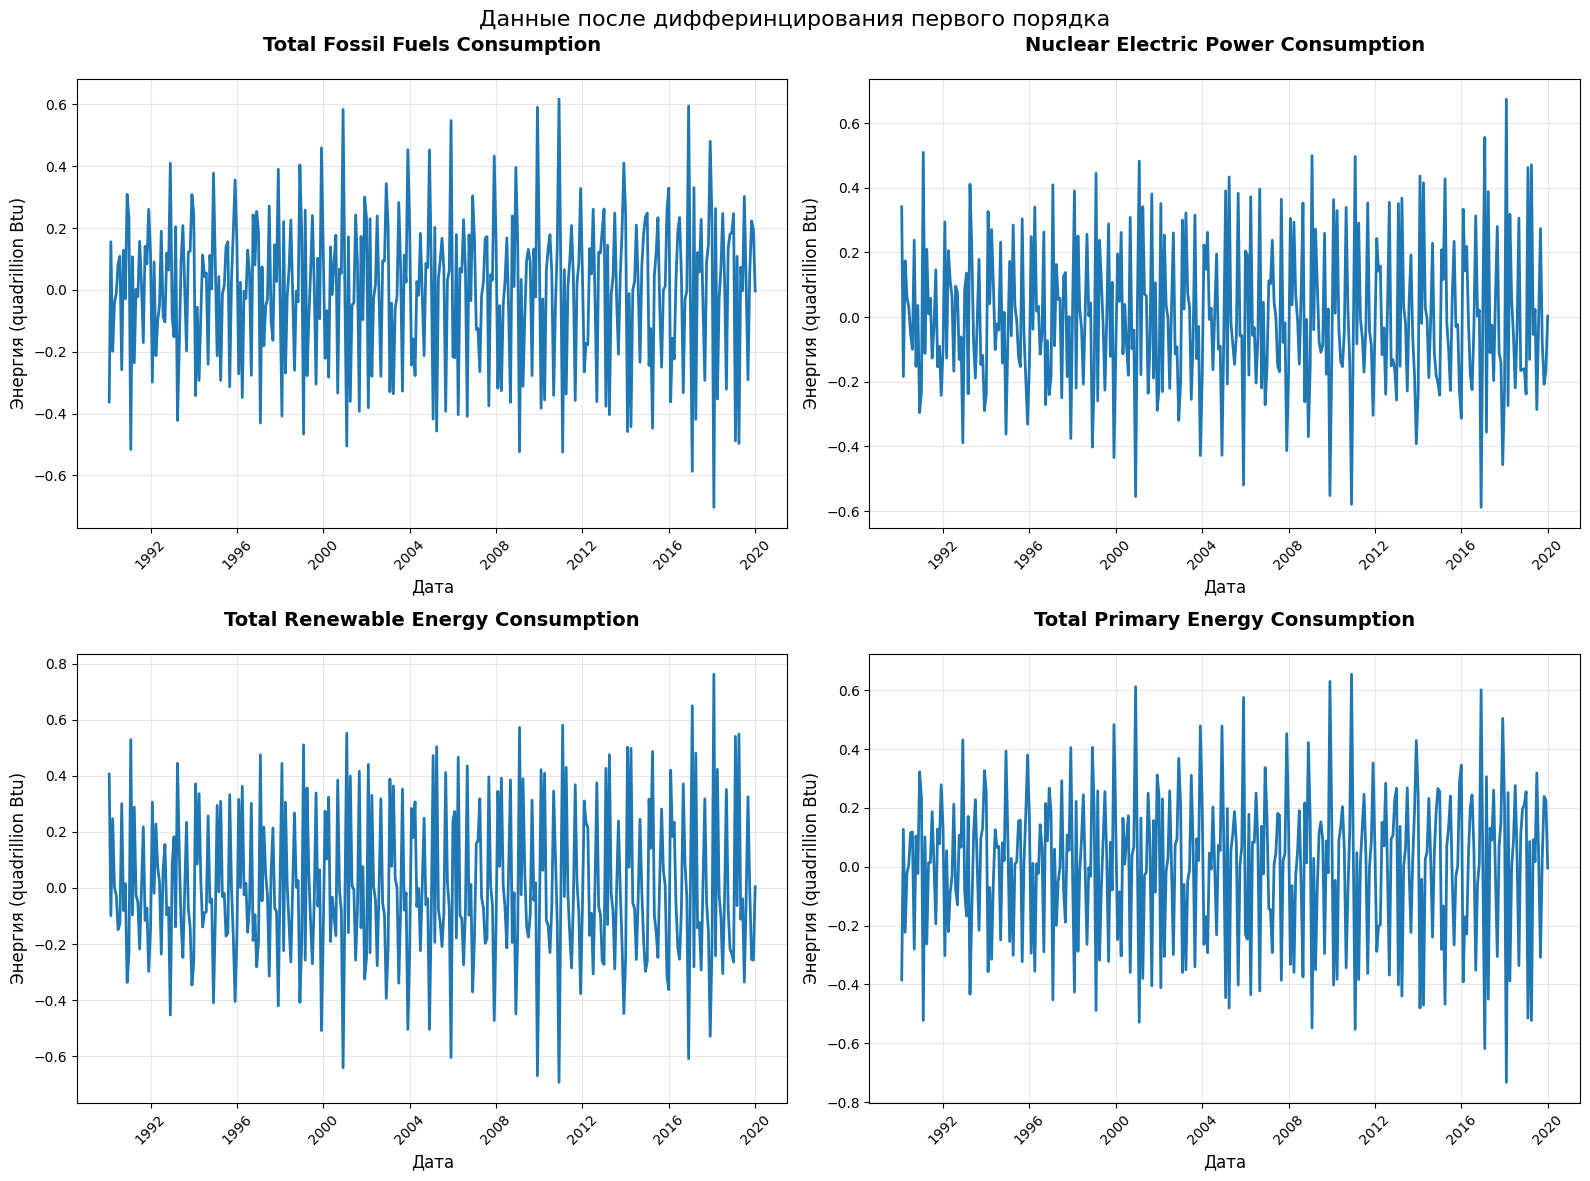

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(consumption_cols):
    axes[i].plot(df_diff.index, df_diff[col], linewidth=2)
    axes[i].set_title(col, fontsize=14, fontweight='bold', pad=20)
    axes[i].set_xlabel('Дата', fontsize=12)
    axes[i].set_ylabel('Энергия (quadrillion Btu)', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Данные после дифферинцирования первого порядка', fontsize=16)
plt.tight_layout()
plt.show()

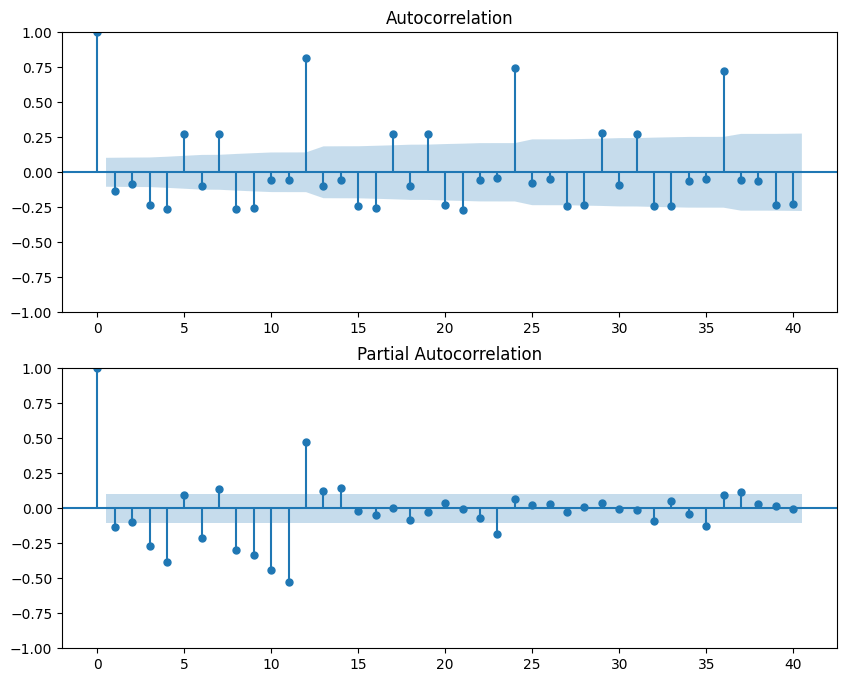

In [52]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(df_diff['Nuclear Electric Power Consumption'], ax=ax[0], lags=40)
plot_pacf(df_diff['Nuclear Electric Power Consumption'], ax=ax[1], lags=40)

plt.show()

Метрики

In [53]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name="Model", column='Column'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{column}")
    print(f"{name}:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print("-" * 30)

    return mae, rmse

split = int(len(df_cons) * 0.8)

# train = df_cons.iloc[:split]
# test = df_cons.iloc[split:]
train = df_log.iloc[:split]
test = df_log.iloc[split:]

# SARIMAX

In [54]:
# from statsmodels.tsa.statespace.sarimax import SARIMAX
#
# sarimax_models = []
#
# for col in consumption_cols:
#     model = SARIMAX(train[col],
#                     order=(1,1,1),
#                     seasonal_order=(1,1,1,12))
#
#     model_fit = model.fit()
#
#     forecast = model_fit.forecast(steps=len(test))
#     sarimax_models.append(model_fit)
#     evaluate(test[col], forecast, name="SARIMA", column=col)

import pmdarima as pm

sarima_models = []
sarima_forecasts = []

for col in consumption_cols:
    model = pm.auto_arima(
        train[col],
        seasonal=True,
        m=12,
        trace=False,
        error_action='ignore',
        suppress_warnings=True
    )

    forecast = model.predict(n_periods=len(test))

    # обратно из логов
    forecast = np.exp(forecast)
    actual = np.exp(test[col])

    sarima_models.append(model)
    sarima_forecasts.append(forecast)

    evaluate(actual, forecast, name="SARIMA (auto)", column=col)

Total Fossil Fuels Consumption
SARIMA (auto):
MAE: 0.1728
RMSE: 0.2215
------------------------------
Nuclear Electric Power Consumption
SARIMA (auto):
MAE: 0.0175
RMSE: 0.0209
------------------------------
Total Renewable Energy Consumption
SARIMA (auto):
MAE: 0.0303
RMSE: 0.0375
------------------------------
Total Primary Energy Consumption
SARIMA (auto):
MAE: 0.1690
RMSE: 0.2202
------------------------------


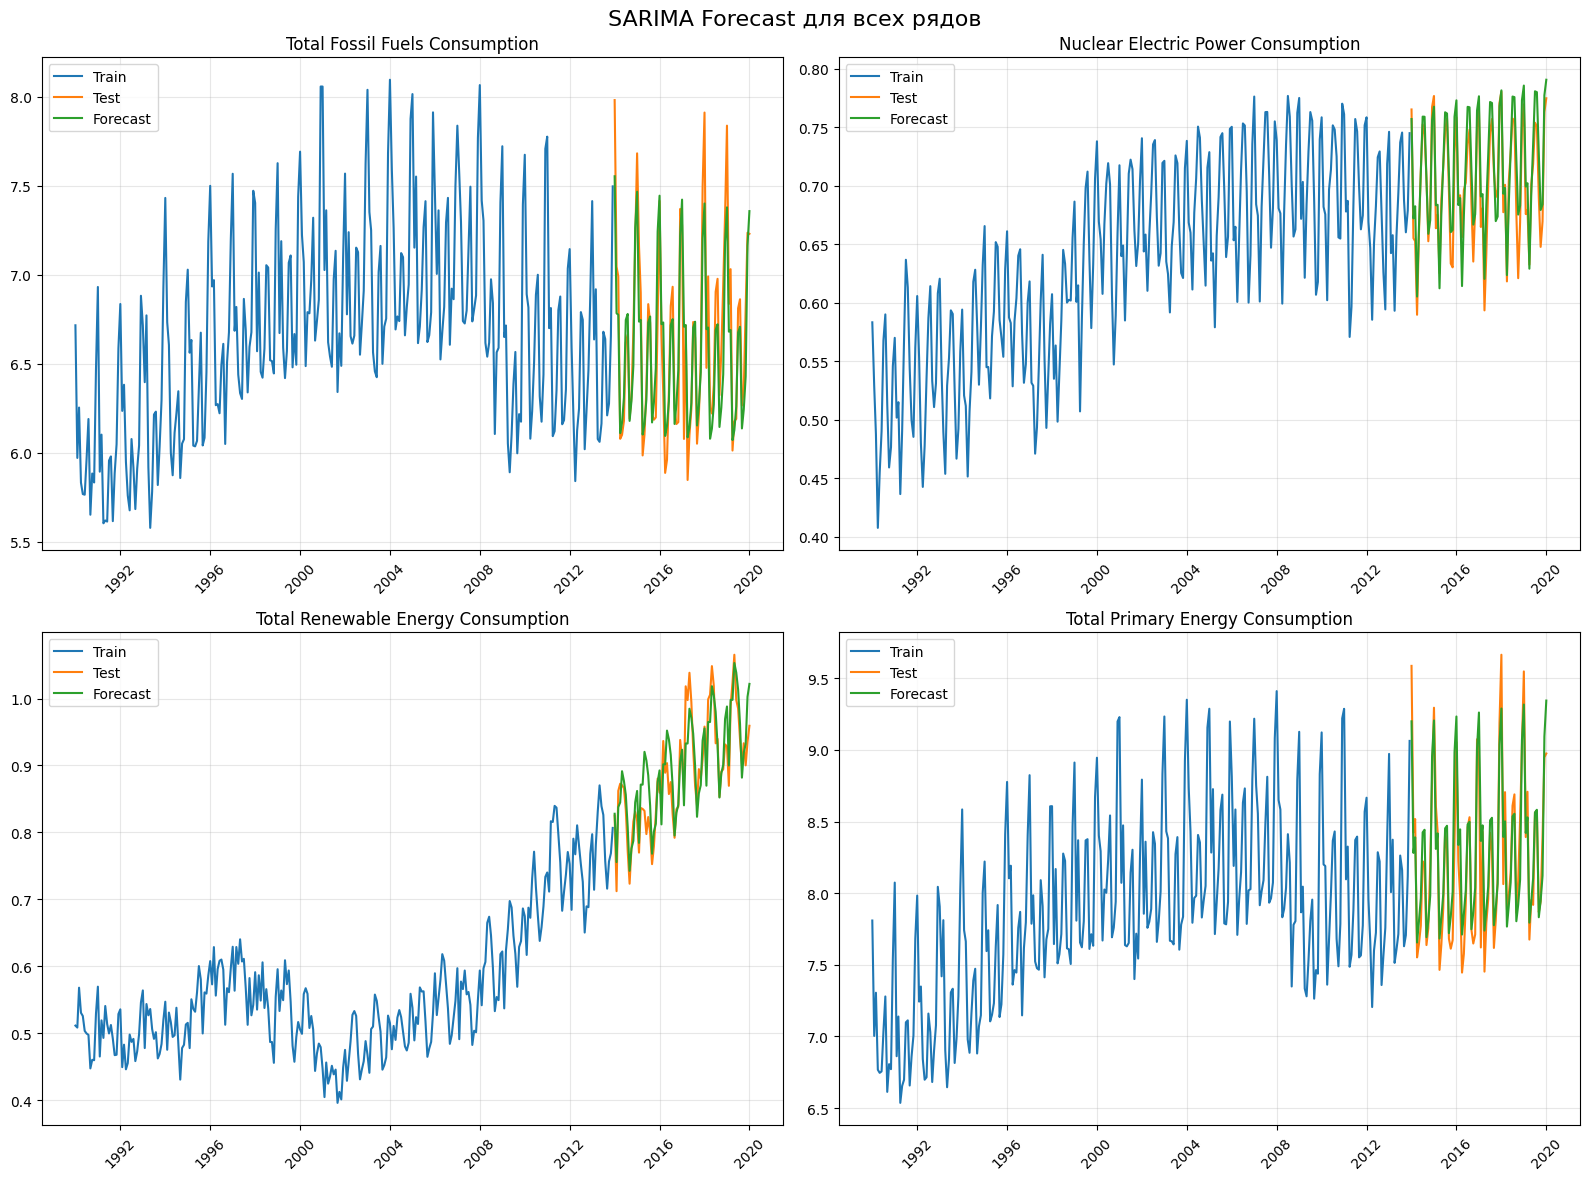

In [55]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# for i, col in enumerate(consumption_cols):
#     forecast = sarimax_models[i].forecast(steps=len(test))
#
#     axes[i].plot(train.index, train[col], label="Train")
#     axes[i].plot(test.index, test[col], label="Test")
#     axes[i].plot(test.index, forecast, label="Forecast")

for i, col in enumerate(consumption_cols):
    forecast = sarima_forecasts[i]

    axes[i].plot(train.index, np.exp(train[col]), label="Train")
    axes[i].plot(test.index, np.exp(test[col]), label="Test")
    axes[i].plot(test.index, forecast, label="Forecast")

    axes[i].set_title(col, fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

plt.suptitle("SARIMA Forecast для всех рядов", fontsize=16)
plt.tight_layout()
plt.show()

# VAR

In [56]:
from statsmodels.tsa.api import VAR
import pandas as pd

# берем только consumption
df_var = df_cons[consumption_cols].copy()

# удаляем линейно зависимую переменную (ВАЖНО!)
df_var = df_var.drop(columns=['Total Primary Energy Consumption'])

# дифференцирование
df_var = df_var.diff().dropna()

# train / test
train_var = df_var.iloc[:split]
test_var = df_var.iloc[split:]

# модель VAR
model = VAR(train_var)

# ограничиваем лаги + авто-выбор
results = model.fit(maxlags=5, ic='aic')

lag_order = results.k_ar

# прогноз
forecast = results.forecast(train_var.values[-lag_order:], steps=len(test_var))

# в DataFrame
forecast_df = pd.DataFrame(forecast, index=test_var.index, columns=df_var.columns)

# оценка
for col in df_var.columns:
    evaluate(test_var[col], forecast_df[col], name="VAR", column=col)

Total Fossil Fuels Consumption
VAR:
MAE: 0.3812
RMSE: 0.4918
------------------------------
Nuclear Electric Power Consumption
VAR:
MAE: 0.0409
RMSE: 0.0473
------------------------------
Total Renewable Energy Consumption
VAR:
MAE: 0.0398
RMSE: 0.0499
------------------------------


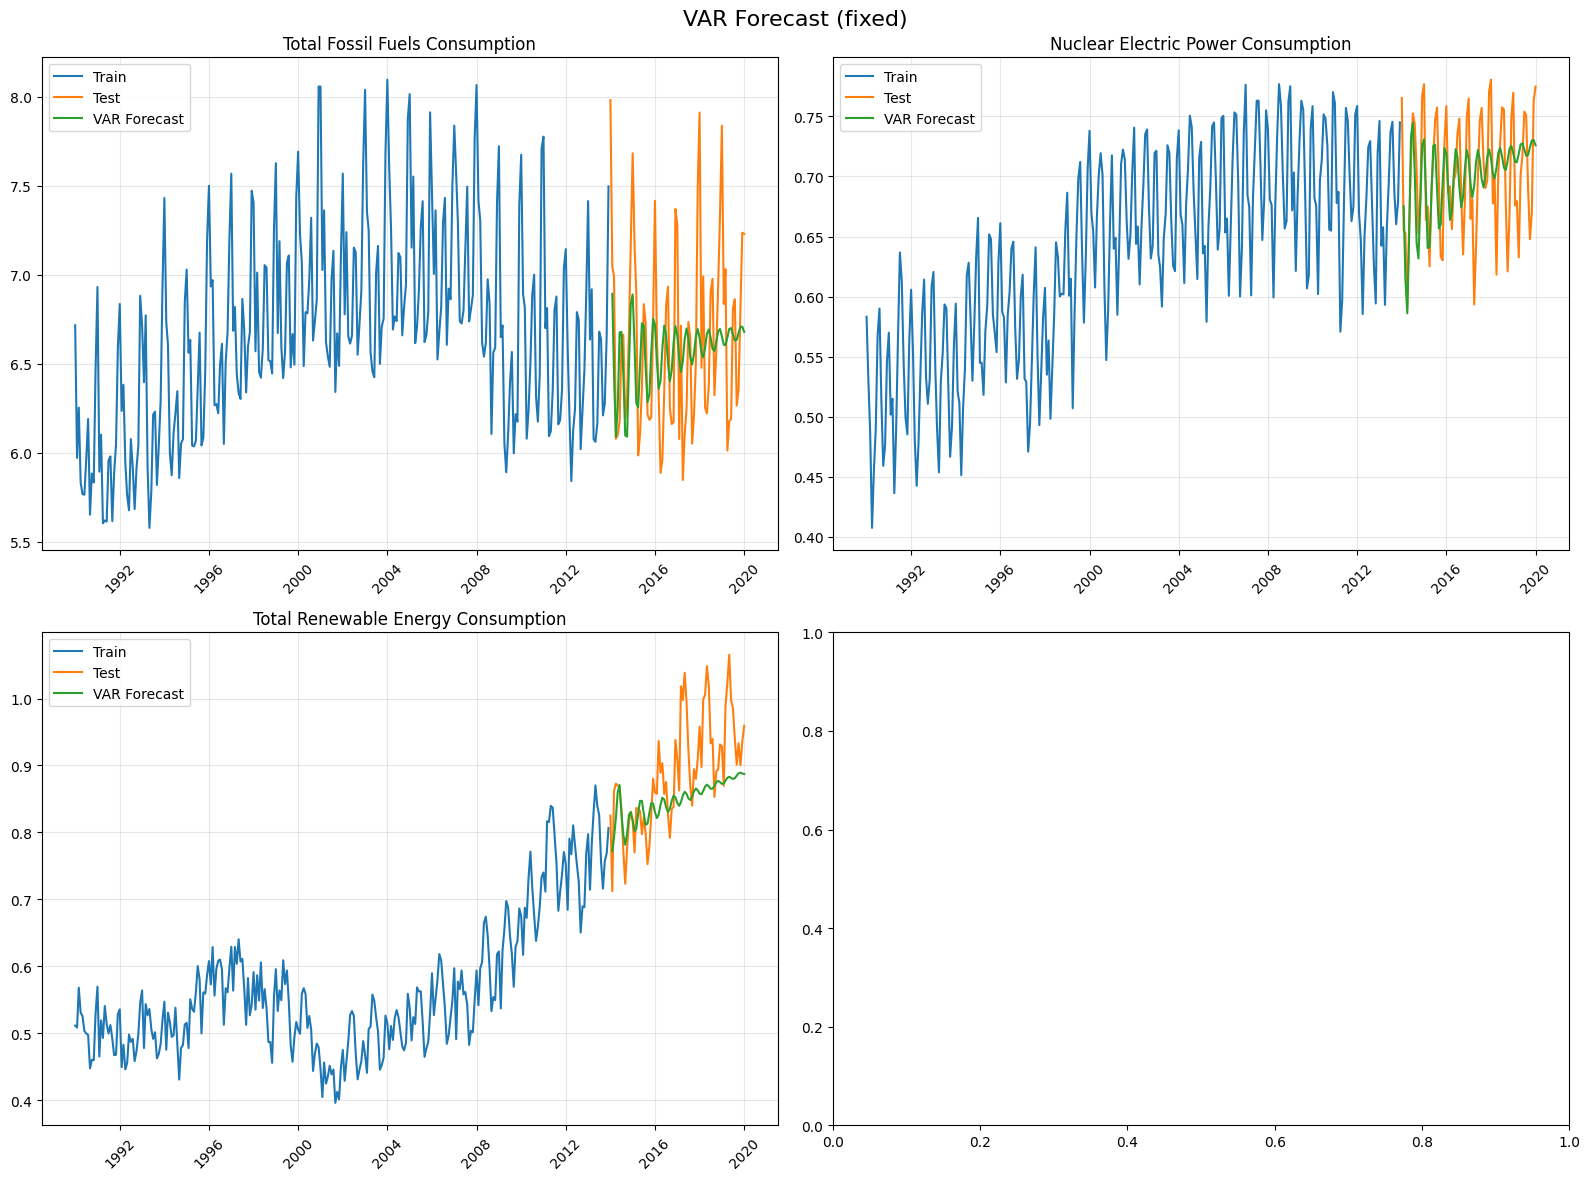

In [57]:
# прогноз (diff)
forecast = results.forecast(train_var.values[-lag_order:], steps=len(test_var))

forecast_df = pd.DataFrame(forecast, index=test_var.index, columns=df_var.columns)

# восстановление уровней
last_train_values = df_cons[df_var.columns].iloc[split-1]
forecast_restored = forecast_df.cumsum() + last_train_values

# графики
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(df_var.columns):

    axes[i].plot(df_cons.index[:split], df_cons[col].iloc[:split], label="Train")
    axes[i].plot(df_cons.index[split:], df_cons[col].iloc[split:], label="Test")

    axes[i].plot(forecast_restored.index, forecast_restored[col], label="VAR Forecast")

    axes[i].set_title(col)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

plt.suptitle("VAR Forecast (fixed)", fontsize=16)
plt.tight_layout()
plt.show()

# GBDT

In [58]:
# df_ml = df_diff.copy()
#
# for col in consumption_cols:
#     df_ml[f'{col}_lag1'] = df_ml[col].shift(1)
#     df_ml[f'{col}_lag12'] = df_ml[col].shift(12)
#
# df_ml = df_ml.dropna()
#
# X = df_ml.drop(columns=consumption_cols)
# y = df_ml[consumption_cols]
#
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.model_selection import train_test_split
#
# gbdt_preds = []
#
# for target in consumption_cols:
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y[target], test_size=0.2, shuffle=False
#     )
#
#     model = GradientBoostingRegressor()
#     model.fit(X_train, y_train)
#
#     pred = model.predict(X_test)
#     gbdt_preds.append(pred)
#     evaluate(y_test, pred, name="Gradient Boosting", column=target)

df_ml = df_log.copy()

# лаги
for col in consumption_cols:
    for lag in [1, 2, 3, 6, 12]:
        df_ml[f'{col}_lag{lag}'] = df_ml[col].shift(lag)

# сезонность
df_ml['sin_month'] = np.sin(2 * np.pi * df_ml.index.month / 12)
df_ml['cos_month'] = np.cos(2 * np.pi * df_ml.index.month / 12)

df_ml = df_ml.dropna()

X = df_ml.drop(columns=consumption_cols)
y = df_ml[consumption_cols]

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

gbdt_preds = []

for target in consumption_cols:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y[target], test_size=0.2, shuffle=False
    )

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    # переводим обратно из log
    pred_restored = np.exp(pred)
    actual = np.exp(y_test)

    gbdt_preds.append(pred_restored)

    evaluate(actual, pred_restored, name="XGBoost", column=target)

Total Fossil Fuels Consumption
XGBoost:
MAE: 0.1925
RMSE: 0.2558
------------------------------
Nuclear Electric Power Consumption
XGBoost:
MAE: 0.0177
RMSE: 0.0216
------------------------------
Total Renewable Energy Consumption
XGBoost:
MAE: 0.1045
RMSE: 0.1230
------------------------------
Total Primary Energy Consumption
XGBoost:
MAE: 0.1741
RMSE: 0.2300
------------------------------


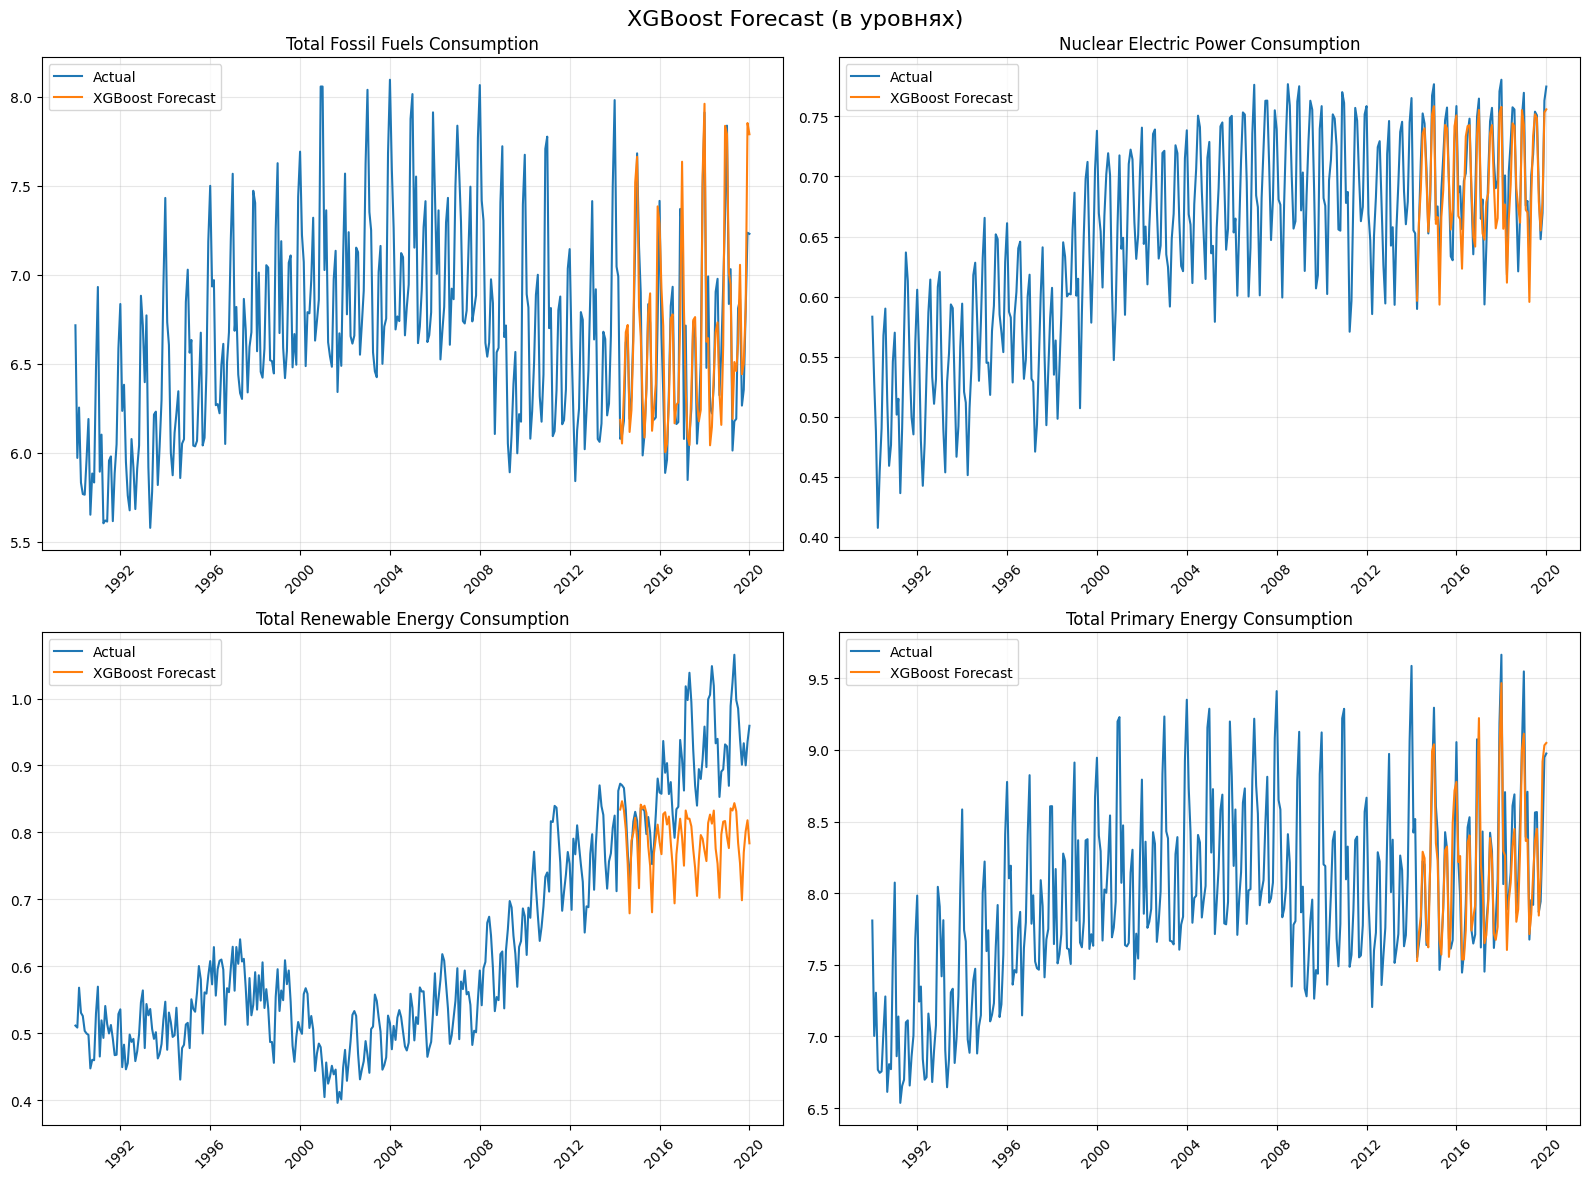

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(consumption_cols):

    # тот же split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y[col], test_size=0.2, shuffle=False
    )

    # уже восстановленные значения!
    pred_restored = pd.Series(gbdt_preds[i], index=y_test.index)

    # графики
    axes[i].plot(df_cons.index, df_cons[col], label="Actual")
    axes[i].plot(pred_restored.index, pred_restored, label="XGBoost Forecast")

    axes[i].set_title(col, fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

plt.suptitle("XGBoost Forecast (в уровнях)", fontsize=16)
plt.tight_layout()
plt.show()